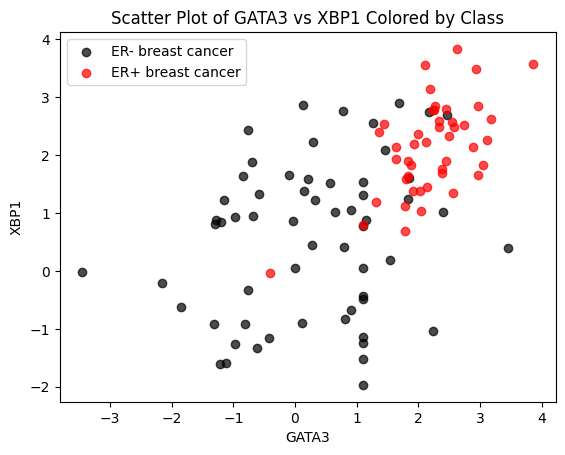

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
expression_df = pd.read_csv("filtered.tsv", sep="\t")
class_labels_df = pd.read_csv("class.tsv", sep="\t", header=None)
gene_info_df = pd.read_csv("columns.tsv", sep="\t", comment="#")    

# Get expression column names for GATA3 and XBP1
gata3_column = " " + str(gene_info_df.loc[gene_info_df['GeneSymbol'] == 'GATA3', 'ID'].values[0])
xbp1_column = " " + str(gene_info_df.loc[gene_info_df['GeneSymbol'] == 'XBP1', 'ID'].values[0])

# Extract expression values
gata3_values = expression_df[gata3_column].values
xbp1_values = expression_df[xbp1_column].values

# Extract class labels
class_labels = class_labels_df[0].values
er_negative_mask = (class_labels == 0)
er_positive_mask = (class_labels == 1)

# Plot
plt.scatter(gata3_values[er_negative_mask], xbp1_values[er_negative_mask],
            color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(gata3_values[er_positive_mask], xbp1_values[er_positive_mask],
            color='red', alpha=0.7, label='ER+ breast cancer')

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by Class")
plt.legend()
plt.show()


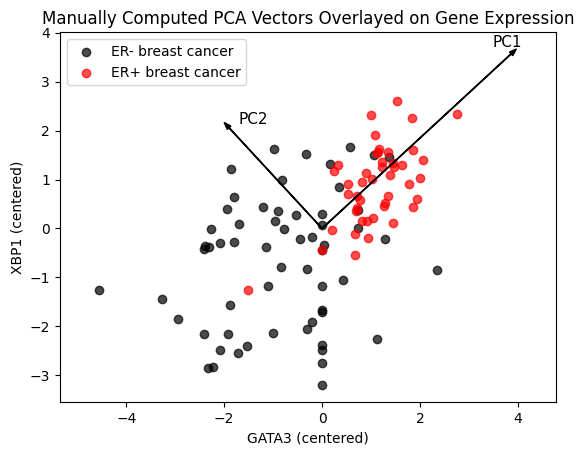

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Rename for clarity and consistency
gata3_expr = gata3_values
xbp1_expr = xbp1_values
class_labels = class_labels

# Stack expression data and center it
expression_data = np.vstack((gata3_expr, xbp1_expr)).T
mean_vector = np.mean(expression_data, axis=0)
centered_data = expression_data - mean_vector

# Compute covariance matrix and its eigen decomposition
cov_matrix = np.cov(centered_data.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

principal_components = eigenvectors.T
explained_variance = eigenvalues

# Define masks for plotting
er_negative_mask = (class_labels == 0)
er_positive_mask = (class_labels == 1)

# Plot centered data with PCA vectors
plt.scatter(centered_data[er_negative_mask, 0], centered_data[er_negative_mask, 1],
            color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(centered_data[er_positive_mask, 0], centered_data[er_positive_mask, 1],
            color='red', alpha=0.7, label='ER+ breast cancer')

# Plot eigenvectors
for i in range(2):
    origin = np.array([0, 0])
    vector = np.sqrt(explained_variance[i]) * principal_components[i] * 3
    plt.arrow(origin[0], origin[1], vector[0], vector[1],
              color='black', width=0.01, head_width=0.1)
    plt.text(vector[0] * 0.9, vector[1] * 1.04, f'PC{i+1}', color='black', fontsize=11)

plt.xlabel("GATA3 (centered)")
plt.ylabel("XBP1 (centered)")
plt.title("Manually Computed PCA Vectors Overlayed on Gene Expression")
plt.legend()
plt.axis('equal')
plt.show()


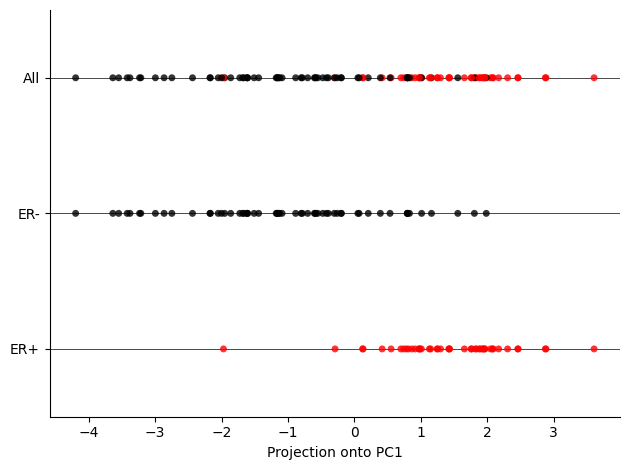

In [8]:
# Compute projection onto first principal component
pc1_vector = eigenvectors[:, 0]
pc1_projection = centered_data @ pc1_vector

# Create DataFrames for plotting
df_all_samples = pd.DataFrame({
    "PC1": pc1_projection,
    "Group": "All",
    "Color": np.where(class_labels == 0, "black", "red")
})

df_er_positive = pd.DataFrame({
    "PC1": pc1_projection[class_labels == 1],
    "Group": "ER+",
    "Color": "red"
})

df_er_negative = pd.DataFrame({
    "PC1": pc1_projection[class_labels == 0],
    "Group": "ER-",
    "Color": "black"
})

# Combine all DataFrames
stripplot_data = pd.concat([df_all_samples, df_er_negative, df_er_positive], ignore_index=True)

# Plot using seaborn
ax = sns.stripplot(
    data=stripplot_data, x="PC1", y="Group", hue="Color",
    palette={"black": "black", "red": "red"},
    dodge=False, jitter=False, alpha=0.8, size=5
)

# Customize plot
ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)
plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)  # Remove legend
sns.despine()
plt.tight_layout()
plt.show()
